# 12-Shadow Deployments & Traffic Mirroring

In Lesson 11, we engineered strict Site Reliability Engineering (SRE) alert thresholds to wake up engineers when an active model fails. However, reacting to a failure means the failure has already occurred, and the business has already suffered damage.

To achieve elite operational maturity, we must prevent the failure from reaching the user in the first place. When Data Scientists develop a new model (the "Challenger"), they test it against static historical data. But historical data cannot simulate real-world chaos, adversarial user behavior, or actual production network latency.

If you deploy the Challenger directly to production, you are taking a blind risk. To mathematically eliminate this risk, we engineer **Shadow Deployments (Traffic Mirroring)**. We duplicate live production traffic at the network layer, routing a mirrored copy of the payload to the Challenger model. The Challenger makes real-time predictions, but its responses are silently logged and **never returned to the user**. We can then mathematically evaluate the Challenger against the active "Champion" model with absolute zero risk to the business.

# 1. The Mathematics of Shadow Routing & Delta Evaluation

### The Request Bifurcation Vector

Let an incoming user HTTP request be defined as the payload matrix $X$.
In a standard topology, the request is routed exclusively to the Champion model ($M_A$):


$$f_{champ}(X) \to \hat{Y}_A$$

In a Shadow Topology, the network gateway clones the payload $X$. It forwards the primary payload to $M_A$ synchronously, and the cloned payload to the Challenger ($M_B$) asynchronously:


$$X \to \begin{cases} M_A(X) = \hat{Y}_A \implies \text{Returned to User (Synchronous)} \\ M_B(X) = \hat{Y}_B \implies \text{Dumped to Telemetry DB (Asynchronous)} \end{cases}$$

### The Isolation Constraint

For a shadow deployment to be safe, it must strictly satisfy the Isolation Constraint. If $M_B$ crashes, experiences a 10-second latency spike, or throws a catastrophic `Out of Memory` exception, the user's interaction with $M_A$ must remain completely unaffected.


$$T_{\text{user\_latency}} = T_{gateway} + T_{M_A}$$


The latency of $M_B$ ($T_{M_B}$) is mathematically decoupled from the critical path.

### The Delta Evaluation Matrix ($\Delta$)

Once both predictions are stored, we evaluate the divergence between the Champion and Challenger without waiting for ground-truth labels. We calculate the Delta matrix $\Delta(\hat{Y}_A, \hat{Y}_B)$.
If $\Delta$ is extremely high, the new model is behaving radically differently than the production model, flagging severe operational risk that must be investigated before a live release.


# 2. Imperative Execution: Application-Layer Mirroring (FastAPI)

If you lack access to a dedicated API Gateway, you can engineer traffic mirroring directly within your Python application logic using asynchronous background tasks.

Let's build a local FastAPI endpoint that processes a live request, returns the safe prediction immediately, and fires the payload to a simulated Challenger model in a decoupled background thread.

In [1]:
# Required installations: pip install fastapi uvicorn requests
from fastapi import FastAPI, BackgroundTasks
import time
import random

print("--- 🚀 Initializing Shadow Deployment Sandbox ---")

app = FastAPI(title="MLOps Shadow Router")

# 1. 🧠 The Champion Model (Safe, Fast, Production-Ready)
def champion_model_predict(payload: dict) -> float:
    # Simulate a stable Random Forest forward pass (50ms)
    time.sleep(0.05)
    return payload["feature_1"] * 0.85

# 2. 🧪 The Challenger Model (Unstable, Experimental, Unpredictable)
def challenger_model_predict(payload: dict, champ_prediction: float):
    print("   [SHADOW THREAD] Executing experimental Challenger model...")
    start_time = time.perf_counter()
    
    try:
        # Simulate a heavy, unstable Neural Network forward pass (500ms)
        time.sleep(0.5)
        
        # Simulate an occasional catastrophic failure in the new code
        if random.random() < 0.2:
            raise RuntimeError("CUDA Out of Memory in Challenger Model")
            
        chall_prediction = payload["feature_1"] * 0.88
        exec_time = time.perf_counter() - start_time
        
        # Log the Delta for offline evaluation
        delta = abs(champ_prediction - chall_prediction)
        print(f"   [SHADOW SUCCESS] Champ: {champ_prediction:.2f} | Chall: {chall_prediction:.2f} | Delta: {delta:.4f} | Latency: {exec_time*1000:.0f}ms")
        
    except Exception as e:
        # The Challenger crashed, but the user is completely unaffected
        print(f"   [SHADOW FAILURE] Challenger crashed: {e}")

# 3. ⚡ The Bifurcated Routing Endpoint
@app.post("/predict")
async def predict_endpoint(payload: dict, background_tasks: BackgroundTasks):
    print(f"\n[NETWORK] Received incoming user payload: {payload}")
    
    # Execute the Champion synchronously
    champ_pred = champion_model_predict(payload)
    
    # Dispatch the payload to the Challenger asynchronously
    # The BackgroundTasks engine removes this from the critical network path
    background_tasks.add_task(challenger_model_predict, payload, champ_pred)
    
    # Return the safe Champion response instantly (User experiences 0 latency penalty)
    print("   [NETWORK] Champion prediction returned to user instantly.")
    return {"prediction": champ_pred, "model": "champion_v1"}

# Execute a simulated request to demonstrate the isolation constraint
print("   ✅ FastAPI Shadow Router Compiled.")
print("   -> Physics: The background task will print to the console *after* the HTTP response resolves.")

--- 🚀 Initializing Shadow Deployment Sandbox ---
   ✅ FastAPI Shadow Router Compiled.
   -> Physics: The background task will print to the console *after* the HTTP response resolves.


# 3. Declarative Execution: Infrastructure-Layer Mirroring (NGINX)

Handling mirroring inside the Python application consumes CPU cycles on the exact same hardware running the Champion model. In true Enterprise MLOps, we push this bifurcation to the **Infrastructure Layer** using an API Gateway like NGINX or Envoy.

Let's compile the declarative NGINX matrix that duplicates network packets natively at the C-kernel level.

In [2]:
import os
import yaml

print("\n--- ⚡ Compiling Declarative Infrastructure Routing (NGINX) ---")

shadow_sandbox = "./shadow_sandbox"
os.makedirs(shadow_sandbox, exist_ok=True)

# 1. 📝 Compile the NGINX Mirror Configuration
nginx_conf = """
events {}

http {
    # Define the Upstream Model Servers
    upstream champion_cluster {
        server host.docker.internal:8000; # The stable production API
    }
    upstream challenger_cluster {
        server host.docker.internal:8001; # The experimental new API
    }

    server {
        listen 80;

        location /predict {
            # 1. The Mirror Directive: Clones the request and sends it to /shadow
            mirror /shadow;
            mirror_request_body on;

            # 2. Route the primary request to the Champion
            proxy_pass http://champion_cluster;
        }

        # 3. The Shadow Endpoint (Invisible to the external internet)
        location = /shadow {
            internal; # Cannot be accessed directly
            proxy_pass http://challenger_cluster;
            proxy_set_header X-Shadow-Traffic "true";
            
            # CRITICAL CONSTRAINT: Ignore responses/errors from the Challenger
            proxy_ignore_client_abort on;
        }
    }
}
"""

conf_path = os.path.join(shadow_sandbox, "nginx.conf")
with open(conf_path, "w") as f:
    f.write(nginx_conf.strip())

print(f"   ✅ NGINX Configuration Compiled: {conf_path}")
print("   -> Physics: NGINX will clone the TCP payload in RAM. The user's TCP connection is bound ONLY to the Champion. If the Challenger's connection times out, NGINX silently drops the packet.")


--- ⚡ Compiling Declarative Infrastructure Routing (NGINX) ---
   ✅ NGINX Configuration Compiled: ./shadow_sandbox/nginx.conf
   -> Physics: NGINX will clone the TCP payload in RAM. The user's TCP connection is bound ONLY to the Champion. If the Challenger's connection times out, NGINX silently drops the packet.


# 4. Visualizing the Bifurcation Topology (Network Flow)

To mathematically comprehend the Isolation Constraint, we must visualize the chronological flow of data and the hard boundaries preventing Challenger failures from bleeding into the user's session.

/tmp/ipykernel_53974/867780696.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((3.5, 4.0), 2.0, 2.0, fill=True, color='#9b59b6', edgecolor='black', linewidth=2))
/tmp/ipykernel_53974/867780696.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 6.0), 3.0, 1.5, fill=True, color='#2ecc71', alpha=0.2, edgecolor='black', linewidth=2))
/tmp/ipykernel_53974/867780696.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 2.0), 3.0, 1.5, fill=True, color='#e74c3c', alpha=0.2, edgecolor='black', linewidth=2))


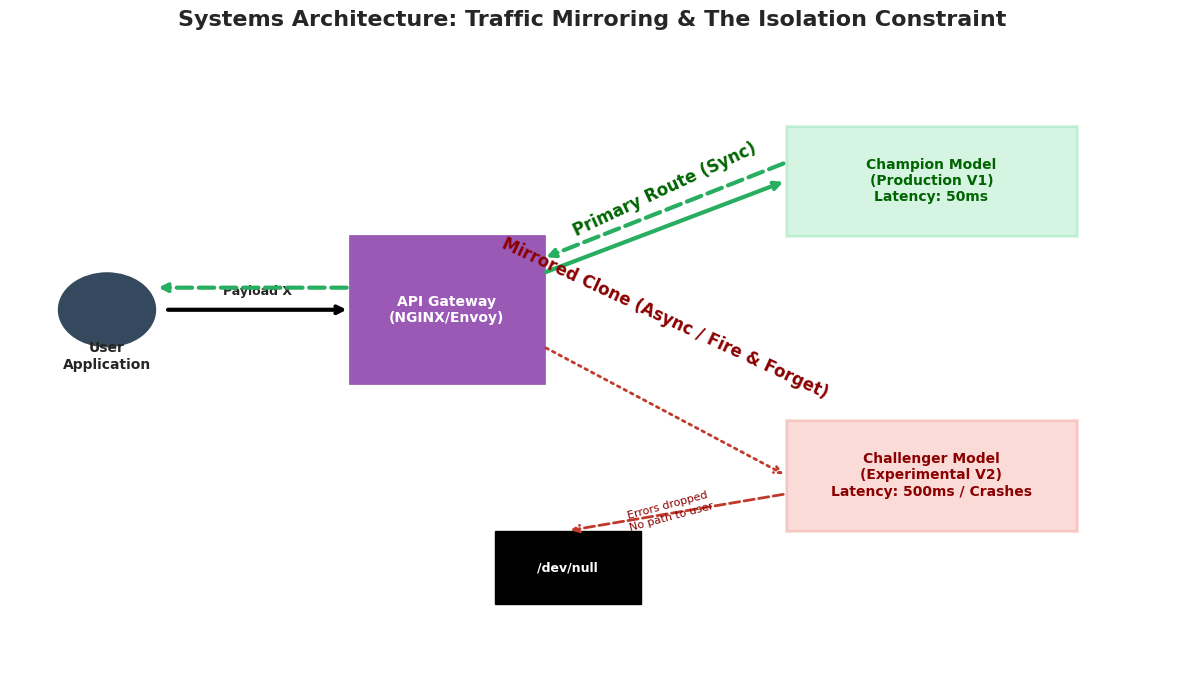

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Systems Architecture: Traffic Mirroring & The Isolation Constraint", fontsize=16, fontweight='bold')
ax.axis('off')

# 1. The External User
ax.add_patch(patches.Circle((1, 5), 0.5, fill=True, color='#34495e'))
ax.text(1, 4.2, "User\nApplication", ha='center', fontweight='bold', fontsize=10)

# 2. The API Gateway / Router
ax.add_patch(patches.Rectangle((3.5, 4.0), 2.0, 2.0, fill=True, color='#9b59b6', edgecolor='black', linewidth=2))
ax.text(4.5, 5.0, "API Gateway\n(NGINX/Envoy)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# 3. The Champion Environment (Production)
ax.add_patch(patches.Rectangle((8.0, 6.0), 3.0, 1.5, fill=True, color='#2ecc71', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(9.5, 6.75, "Champion Model\n(Production V1)\nLatency: 50ms", ha='center', va='center', color='darkgreen', fontweight='bold', fontsize=10)

# 4. The Challenger Environment (Shadow)
ax.add_patch(patches.Rectangle((8.0, 2.0), 3.0, 1.5, fill=True, color='#e74c3c', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(9.5, 2.75, "Challenger Model\n(Experimental V2)\nLatency: 500ms / Crashes", ha='center', va='center', color='darkred', fontweight='bold', fontsize=10)

# 5. Connective Vectors (The Critical Path vs The Asynchronous Path)
# User to Gateway
ax.annotate("", xy=(3.5, 5.0), xytext=(1.6, 5.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(2.55, 5.2, "Payload X", ha='center', fontweight='bold', fontsize=9)

# Gateway to Champion (Synchronous)
ax.annotate("", xy=(8.0, 6.75), xytext=(5.5, 5.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.annotate("", xy=(5.5, 5.7), xytext=(8.0, 7.0), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", linestyle="--"))
ax.annotate("", xy=(1.5, 5.3), xytext=(3.5, 5.3), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", linestyle="--"))
ax.text(6.75, 6.0, "Primary Route (Sync)", ha='center', color='darkgreen', fontweight='bold', rotation=25)

# Gateway to Challenger (Asynchronous Mirror)
ax.annotate("", xy=(8.0, 2.75), xytext=(5.5, 4.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b", linestyle="dotted"))
ax.text(6.75, 3.8, "Mirrored Clone (Async / Fire & Forget)", ha='center', color='darkred', fontweight='bold', rotation=-25)

# The Void (Failed responses do not return)
ax.add_patch(patches.Rectangle((5.0, 1.0), 1.5, 1.0, fill=True, color='black'))
ax.text(5.75, 1.5, "/dev/null", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.annotate("", xy=(5.75, 2.0), xytext=(8.0, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b", linestyle="dashed"))
ax.text(6.8, 2.0, "Errors dropped\nNo path to user", ha='center', color='darkred', fontsize=8, rotation=15)

plt.xlim(0, 12)
plt.ylim(0, 8.5)
plt.tight_layout()
plt.show()

*(Insight: The green path represents the rigid Synchronous loop. The user waits strictly for the green dashed line to return. The red dotted line is a Fire-and-Forget clone. Whether the Challenger takes 500ms, crashes, or succeeds, its return trajectory terminates at `/dev/null` regarding the API gateway response cycle, strictly preserving the user experience.)*

## Real-World Use Case or Analogy

Think of Traffic Mirroring like **Training an Apprentice Chef in a Michelin-Star Restaurant**:

* **The Champion (The Head Chef):** A customer orders a highly complex soufflé. The head chef takes the order, cooks the soufflé flawlessly, and the waiter serves it to the customer. The customer is happy and leaves a 5-star review.
* **The Challenger (The Apprentice Chef):** You recently hired a new apprentice and want to see if they are ready to replace the head chef.
* **A Direct Deployment (The Catastrophic Risk):** You fire the head chef and tell the apprentice to cook the soufflé for the live customer. The apprentice panics, burns the soufflé, and sets the kitchen on fire. The customer leaves a 1-star review, and your restaurant's reputation is destroyed.
* **Traffic Mirroring (The Shadow Kitchen):** You keep the head chef on the line. When the order ticket comes in, you print **two copies** of the ticket.
* You hand Copy A to the Head Chef. The Head Chef cooks the meal, and the waiter serves it to the customer (**The Synchronous Critical Path**).
* You hand Copy B to the Apprentice Chef in a separate back kitchen. The apprentice attempts to cook the exact same meal.
* When the apprentice finishes, the waiter does *not* serve it to the customer. Instead, the Restaurant Manager tastes it, writes down notes comparing it to the Head Chef's version (**The Delta Evaluation Matrix**), and throws the apprentice's meal in the trash (**`/dev/null`**).



By utilizing Shadow Deployments, MLOps engineers force their new models to face the absolute brutality of live production traffic—testing them against the exact same data distributions, edge cases, and inference volume as the active model—without exposing the business to a single ounce of risk.